In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from pathlib import Path


In [11]:
# Conectar con la base de datos y cargar las 3 tablas
import sqlite3

# Crear la conexión a la base de datos
conn = sqlite3.connect('../datos/intermedios/analisis_inmobiliario.db')

listings = pd.read_sql_query("SELECT * FROM listings", conn)
listings_det = pd.read_sql_query("SELECT * FROM listings_det", conn)
precio = pd.read_sql_query("SELECT * FROM idealista", conn)

conn.close()

In [12]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 18708 entries, 0 to 18707
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   18708 non-null  int64  
 1   name                 18708 non-null  str    
 2   neighbourhood_group  18708 non-null  str    
 3   neighbourhood        18708 non-null  str    
 4   latitude             18708 non-null  float64
 5   longitude            18708 non-null  float64
 6   room_type            18708 non-null  str    
 7   price                18708 non-null  float64
 8   minimum_nights       18708 non-null  int64  
 9   availability_365     18708 non-null  int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 1.4 MB


In [13]:
# Cambiar el tipo de dato de las columnas name, neighborhood, neighborhood_group, room_type a object
listings['name'] = listings['name'].astype(object)
listings['neighbourhood'] = listings['neighbourhood'].astype(object)
listings['neighbourhood_group'] = listings['neighbourhood_group'].astype(object)
listings['room_type'] = listings['room_type'].astype(object)

In [14]:
listings_det.info()

<class 'pandas.DataFrame'>
RangeIndex: 14067 entries, 0 to 14066
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         14067 non-null  int64  
 1   description                13692 non-null  str    
 2   accommodates               14067 non-null  int64  
 3   bathrooms                  14067 non-null  float64
 4   bedrooms                   14067 non-null  float64
 5   beds                       14067 non-null  float64
 6   review_scores_location     14067 non-null  float64
 7   estimated_occupancy_l365d  14067 non-null  int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 879.3 KB


In [15]:
# Cambiar la columna description a object
listings_det['description'] = listings_det['description'].astype(object)

In [16]:
precio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   precio    21 non-null     int64
 1   distrito  21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


In [17]:
# Cambiar la columna distrito a object
precio['distrito'] = precio['distrito'].astype(object)

In [18]:
# Merge inner join entre listings y listings_det
df_listings = listings.merge(listings_det, on='id', how='inner')

In [19]:
df_listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 13984 entries, 0 to 13983
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         13984 non-null  int64  
 1   name                       13984 non-null  object 
 2   neighbourhood_group        13984 non-null  object 
 3   neighbourhood              13984 non-null  object 
 4   latitude                   13984 non-null  float64
 5   longitude                  13984 non-null  float64
 6   room_type                  13984 non-null  object 
 7   price                      13984 non-null  float64
 8   minimum_nights             13984 non-null  int64  
 9   availability_365           13984 non-null  int64  
 10  description                13610 non-null  object 
 11  accommodates               13984 non-null  int64  
 12  bathrooms                  13984 non-null  float64
 13  bedrooms                   13984 non-null  float64
 14  b

In [20]:
# Merge entre df_listings y precio (left join)
df = df_listings.merge(precio, left_on='neighbourhood_group', right_on='distrito', how='left')

In [21]:
# Eliminar neighbourhood_group
df = df.drop(columns=['id','neighbourhood_group'])

In [22]:
# Renombrar la columna price a precio_noche y precio a precio_m2
df = df.rename(columns={'price': 'precio_noche', 'precio': 'precio_m2'})

In [23]:
df.head(5)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,bathrooms,bedrooms,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito
0,Apartamentos Dana Sol,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,342,NaN,2,1.0,1.0,2.0,4.90,10,7524,Centro
1,Apartasol Apartamentos Dana,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,341,NaN,2,1.0,1.0,3.0,4.88,40,7524,Centro
2,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Justicia,40.41884,-3.69655,Private room,65.0,1,299,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,1.5,1.0,2.0,4.97,246,7524,Centro
3,Adorable Apartment Malasaña-Gran Via,Universidad,40.42252,-3.70250,Entire home/apt,116.0,30,305,Beautiful apartment with spacious living room ...,2,1.0,1.0,1.0,4.60,60,7524,Centro
4,"Heart of Malasaña Cozy, Quiet & Sunny Apartment",Universidad,40.42252,-3.70250,Entire home/apt,79.0,30,317,Cozy Apartment in great location in the center...,2,1.0,1.0,2.0,4.87,120,7524,Centro


In [24]:
# Crear la variable 'precio_noche_total' según las reglas indicadas

def calcular_precio_noche_total(row):
    tasa_uso = 0.5
    if row['room_type'] == 'Entire home/apt':
        return row['precio_noche']
    elif row['room_type'] == 'Private room':
        return row['precio_noche'] * row['bedrooms'] * tasa_uso
    elif row['room_type'] == 'Shared room':
        return row['precio_noche'] * row['accommodates'] * tasa_uso
    else:
        return np.nan

# Aplicar la función al DataFrame principal (ajusta el nombre del DataFrame si es necesario)
df['precio_noche_total'] = df.apply(calcular_precio_noche_total, axis=1)


In [25]:
# Crear una variable ingreso anual que multiplique el precio_noche_total por estimated_occupancy_l365d
df['ingreso_anual'] = df['precio_noche_total'] * df['estimated_occupancy_l365d']

In [26]:
df.head(5)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,bathrooms,bedrooms,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito,precio_noche_total,ingreso_anual
0,Apartamentos Dana Sol,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,342,NaN,2,1.0,1.0,2.0,4.90,10,7524,Centro,157.0,1570.0
1,Apartasol Apartamentos Dana,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,341,NaN,2,1.0,1.0,3.0,4.88,40,7524,Centro,143.0,5720.0
2,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Justicia,40.41884,-3.69655,Private room,65.0,1,299,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,1.5,1.0,2.0,4.97,246,7524,Centro,32.5,7995.0
3,Adorable Apartment Malasaña-Gran Via,Universidad,40.42252,-3.70250,Entire home/apt,116.0,30,305,Beautiful apartment with spacious living room ...,2,1.0,1.0,1.0,4.60,60,7524,Centro,116.0,6960.0
4,"Heart of Malasaña Cozy, Quiet & Sunny Apartment",Universidad,40.42252,-3.70250,Entire home/apt,79.0,30,317,Cozy Apartment in great location in the center...,2,1.0,1.0,2.0,4.87,120,7524,Centro,79.0,9480.0


In [27]:
condiciones_m2= [
    (df['bedrooms'] == 0),
    (df['bedrooms'] == 1),
    (df['bedrooms'] == 2),
    (df['bedrooms'] == 3) & (df['bathrooms'] < 2),
    (df['bedrooms'] == 3) & (df['bathrooms'] >= 2),
    (df['bedrooms'] > 3) | (df['bathrooms'] >= 3)
]

valores_m2 = [35, 50, 65, 90, 110, 140]

df['m2_estimado'] = np.select(condiciones_m2, valores_m2, default=np.nan)

In [28]:
# Crear una nueva variable llamada coste_adquisicion que multiplique el m2_estimado por el precio_m2 y multiplicar por un ajuste de 0.75
df['coste_adquisicion'] = df['m2_estimado'] * df['precio_m2'] * 0.75

In [29]:
df.head(15)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,...,bedrooms,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito,precio_noche_total,ingreso_anual,m2_estimado,coste_adquisicion
0,Apartamentos Dana Sol,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,342,NaN,2,...,1.0,2.0,4.90,10,7524,Centro,157.0,1570.0,50.0,282150.0
1,Apartasol Apartamentos Dana,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,341,NaN,2,...,1.0,3.0,4.88,40,7524,Centro,143.0,5720.0,50.0,282150.0
2,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Justicia,40.41884,-3.69655,Private room,65.0,1,299,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,...,1.0,2.0,4.97,246,7524,Centro,32.5,7995.0,50.0,282150.0
3,Adorable Apartment Malasaña-Gran Via,Universidad,40.42252,-3.70250,Entire home/apt,116.0,30,305,Beautiful apartment with spacious living room ...,2,...,1.0,1.0,4.60,60,7524,Centro,116.0,6960.0,50.0,282150.0
4,"Heart of Malasaña Cozy, Quiet & Sunny Apartment",Universidad,40.42252,-3.70250,Entire home/apt,79.0,30,317,Cozy Apartment in great location in the center...,2,...,1.0,2.0,4.87,120,7524,Centro,79.0,9480.0,50.0,282150.0
5,Sunny attic duplex flat with terrace next to Sol,Embajadores,40.41150,-3.70449,Entire home/apt,300.0,3,180,"Nestled in the serene heart of Madrid, this re...",6,...,3.0,5.0,4.84,90,7524,Centro,300.0,27000.0,90.0,507870.0
6,Cozy attic with intimate rooftop terrace+ elev...,Embajadores,40.40939,-3.69812,Entire home/apt,166.0,3,150,"Nestled in Madrid's tranquil heart, this apart...",6,...,3.0,3.0,4.92,126,7524,Centro,166.0,20916.0,90.0,507870.0
7,ROOM IN THE CENTER -LA LATINA- WIFI,Palacio,40.41143,-3.70912,Private room,45.0,1,116,NaN,2,...,1.0,2.0,4.95,198,7524,Centro,22.5,4455.0,50.0,282150.0
8,private house B & B. Arturo Soria (Metro),Piovera,40.45575,-3.64912,Private room,90.0,1,336,"Residential area, very quite house, no more gu...",2,...,1.0,2.0,4.84,54,5321,Hortaleza,45.0,2430.0,50.0,199537.5
9,Habitación en ático muy céntrico con dos terrazas,Universidad,40.42570,-3.70383,Private room,60.0,2,257,"Room with new orthopedic mattress, ceiling fan...",2,...,1.0,1.0,4.96,156,7524,Centro,30.0,4680.0,50.0,282150.0


In [30]:
# Crear una media de adquisicion por distrito y mostrarla ordenada de mayor a menor
df.groupby('distrito')['coste_adquisicion'].mean().reset_index().sort_values(by='coste_adquisicion', ascending=False)

,distrito,coste_adquisicion
14,Salamanca,469136.975806
5,Chamberí,384518.520039
4,Chamartín,349893.076110
13,Retiro,344088.173077
3,Centro,320247.526596
10,Moncloa - Aravaca,267627.846535
0,Arganzuela,263039.979196
16,Tetuán,250016.954644
8,Hortaleza,229269.908940
7,Fuencarral - El Pardo,229006.688596


In [31]:
import sys
sys.path.append('../funciones')
from funciones import tourism_index

In [32]:
# Cargar los CSV y convertirlos a diccionarios
df_pois = pd.read_csv('../datos/brutos/poi_madrid.csv')
pois = dict(zip(df_pois['nombre'], zip(df_pois['latitud'], df_pois['longitud'])))

df_weights = pd.read_csv('../datos/brutos/poi_madrid_weights.csv')
weights = dict(zip(df_weights['nombre'], df_weights['peso']))

# Calcular el atractivo turístico
df['atractivo_turistico'] = df.apply(
    lambda row: tourism_index(row['latitude'], row['longitude'], pois, weights), axis=1
)

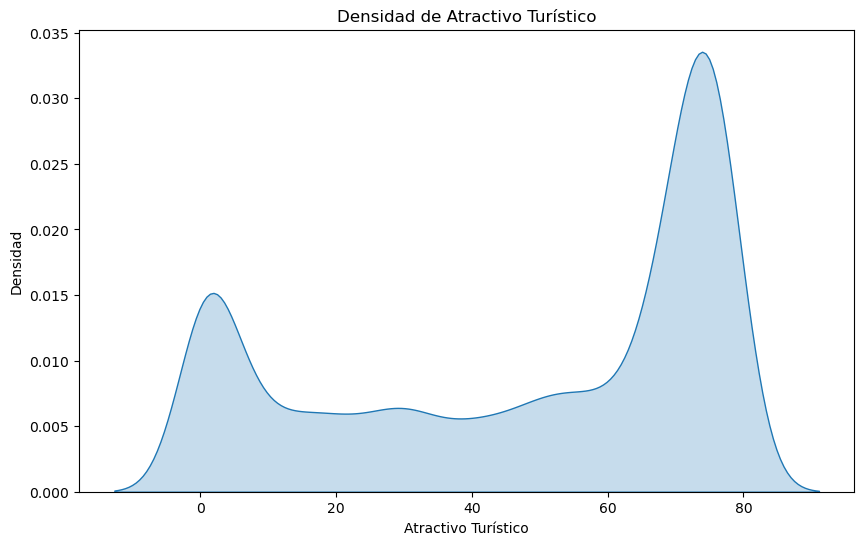

In [33]:
# Grafico de densidad de atractivo turistico
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='atractivo_turistico', fill=True)
plt.title('Densidad de Atractivo Turístico')
plt.xlabel('Atractivo Turístico')
plt.ylabel('Densidad')
plt.show()

In [34]:
# Ordenar df por atractivo turistico de menor a mayor
df.sort_values(by='atractivo_turistico', ascending=True)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,...,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito,precio_noche_total,ingreso_anual,m2_estimado,coste_adquisicion,atractivo_turistico
11177,Trébol hab 1,Casco Histórico de Barajas,40.473408,-3.576329,Private room,64.0,1,287,Get away from routine at this unique and relax...,2,...,2.0,4.79,255,4973,Barajas,32.0,8160.0,50.0,186487.5,0.000000
11841,Habitación con terraza en Madrid,Rosas,40.430050,-3.601430,Private room,90.0,1,323,"If you stayed hanging in Madrid one night, you...",2,...,1.0,5.00,66,3959,San Blas - Canillejas,45.0,2970.0,50.0,148462.5,0.000000
8821,"Madrid Villaverde IV, Estudio con patio y AC",Los Rosales,40.350024,-3.690032,Entire home/apt,89.0,1,349,This cozy studio features an interior patio an...,3,...,2.0,4.38,42,2934,Villaverde,89.0,3738.0,50.0,110025.0,0.000000
8819,"Madrid Villaverde II, Acogedor apartamento, AC",Los Rosales,40.349952,-3.690002,Entire home/apt,82.0,1,346,This cozy apartment is located near Parque de ...,4,...,2.0,4.50,54,2934,Villaverde,82.0,4428.0,50.0,110025.0,0.000000
1264,"Lovely double bedroom, 10 minuts from Airport",Casco Histórico de Barajas,40.475180,-3.582240,Private room,67.0,1,350,Big and comfortable bedroom close to Adolfo Su...,2,...,1.0,4.91,255,4973,Barajas,33.5,8542.5,50.0,186487.5,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,Beautiful Apt. Historic District-Sol,Sol,40.416910,-3.703740,Entire home/apt,210.0,1,80,The apartment is disinfected according to the ...,6,...,3.0,4.89,255,7524,Centro,210.0,53550.0,65.0,366795.0,78.432304
8187,Apartamento de diseño en Sol,Sol,40.416913,-3.703906,Entire home/apt,67.0,1,156,Luxurious apartment in the heart of downtown M...,4,...,3.0,5.00,6,7524,Centro,67.0,402.0,65.0,366795.0,78.432384
133,Best Deal Chic VELAZQUEZ SUITE SOL,Sol,40.416880,-3.703840,Entire home/apt,159.0,2,202,NaN,5,...,3.0,4.86,255,7524,Centro,159.0,40545.0,65.0,366795.0,78.433612
5357,Waou Apartamentos en Sol Superior 1,Sol,40.417110,-3.703710,Entire home/apt,184.0,1,312,Wonderful one bedroom and one bathroom apartme...,4,...,2.0,4.96,96,7524,Centro,184.0,17664.0,50.0,282150.0,78.433927


In [35]:
df.columns

Index(['name', 'neighbourhood', 'latitude', 'longitude', 'room_type',
       'precio_noche', 'minimum_nights', 'availability_365', 'description',
       'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'review_scores_location', 'estimated_occupancy_l365d', 'precio_m2',
       'distrito', 'precio_noche_total', 'ingreso_anual', 'm2_estimado',
       'coste_adquisicion', 'atractivo_turistico'],
      dtype='str')

C:\Users\phdel\AppData\Local\Temp\ipykernel_14284\2946063088.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='accommodates', palette='viridis')


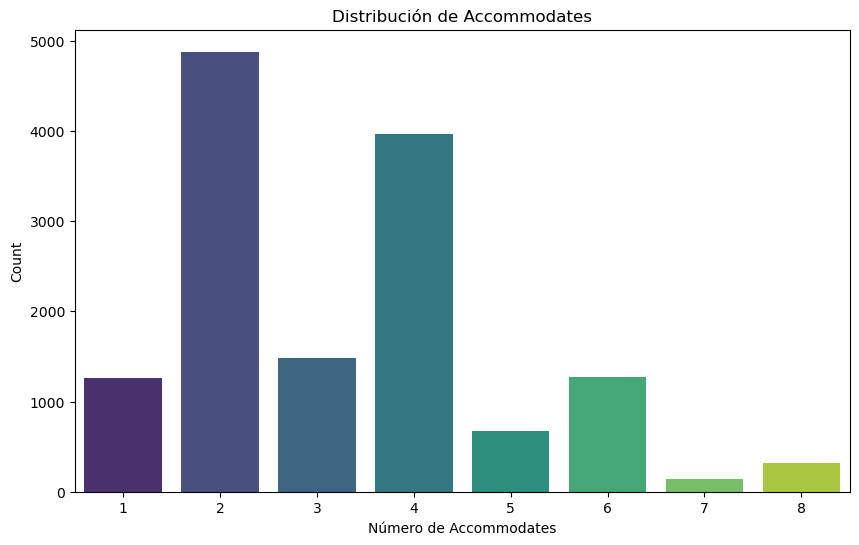

In [37]:
 # Genera un grafico de barras de bedrooms
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='accommodates', palette='viridis')
plt.title('Distribución de Accommodates')
plt.xlabel('Número de Accommodates')
plt.ylabel('Count')
plt.show()

C:\Users\phdel\AppData\Local\Temp\ipykernel_3272\3721838764.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='bathrooms_disc', palette='viridis', order=orden)


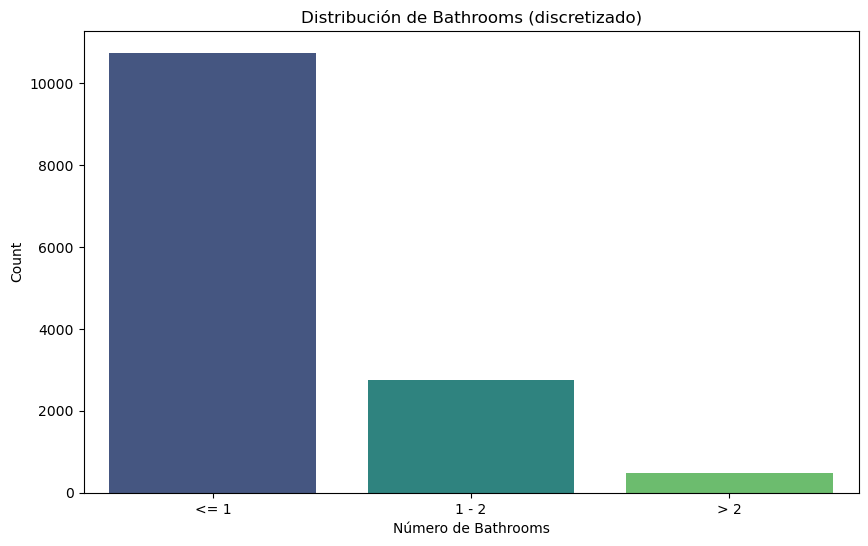

In [ ]:
# Gráfico de barras de bathrooms discretizado con tamaño personalizado
orden = ['<= 1', '1 - 2', '> 2']
df['bathrooms_disc'] = pd.Categorical(df['bathrooms_disc'], categories=orden, ordered=True)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='bathrooms_disc', palette='viridis', order=orden)
plt.title('Distribución de Bathrooms (discretizado)')
plt.xlabel('Número de Bathrooms')
plt.ylabel('Count')
plt.show()

In [ ]:
# Discretizar bathrooms en las categorías '<= 1', '1 - 2', '> 2'
df['bathrooms_disc'] = pd.cut(df['bathrooms'], bins=[-np.inf, 1, 2, np.inf], labels=['<= 1', '1 - 2', '> 2'])

In [40]:
# Discretizar accommodates en las categorías '1', '2', '3', '4', '> 5'
df['accommodates_disc'] = pd.cut(df['accommodates'], bins=[-np.inf, 1, 2, 3, 4, np.inf], labels=['1', '2', '3', '4', '> 5'])

C:\Users\phdel\AppData\Local\Temp\ipykernel_14284\3564817298.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='accommodates_disc', order=orden_accommodates, palette='viridis')


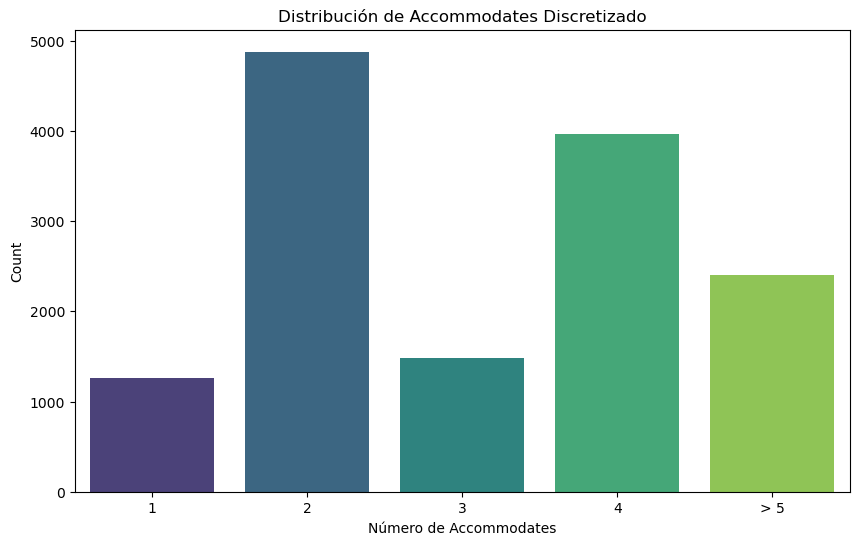

In [41]:
# Grafico de barras de accommodates discretizado con tamaño personalizado
orden_accommodates = ['1', '2', '3', '4', '> 5']
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='accommodates_disc', order=orden_accommodates, palette='viridis')
plt.title('Distribución de Accommodates Discretizado')
plt.xlabel('Número de Accommodates')
plt.ylabel('Count')
plt.show()  
    

In [42]:
# Discretizar beds en las categorías '<=1', '2', '3', '4', '> 5'
df['beds_disc'] = pd.cut(df['beds'], bins=[-np.inf, 1, 2, 3, 4, np.inf], labels=['<=1', '2', '3', '4', '> 5'])

C:\Users\phdel\AppData\Local\Temp\ipykernel_14284\26831797.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='beds_disc', order=orden_beds, palette='viridis')


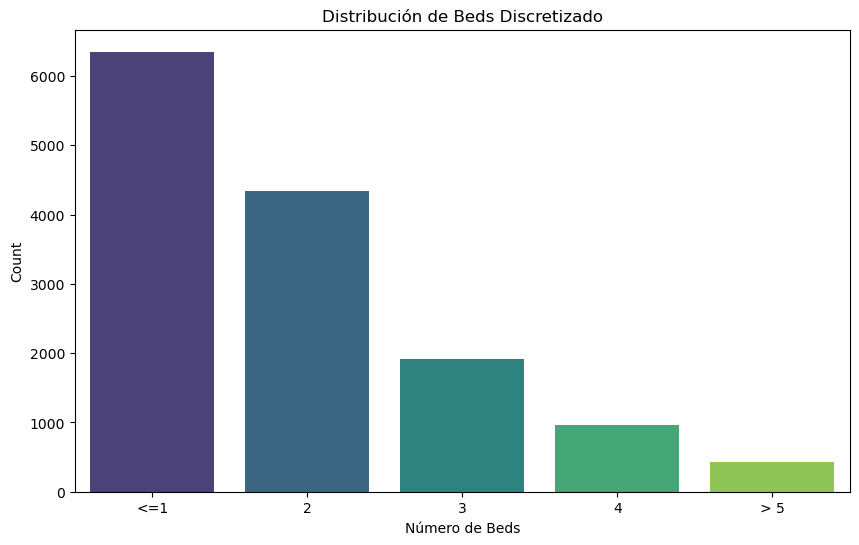

In [43]:
# Grafico de barras de beds discretizado con tamaño personalizado
orden_beds = ['<=1', '2', '3', '4', '> 5']
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='beds_disc', order=orden_beds, palette='viridis')
plt.title('Distribución de Beds Discretizado')
plt.xlabel('Número de Beds')
plt.ylabel('Count')
plt.show()  

In [44]:
# Crea una nueva tabla en la base de datos mercado inmobiliario.db que se llame tablon_analitico con el dataframe df
conn = sqlite3.connect('../datos/intermedios/analisis_inmobiliario.db')
df.to_sql('tablon_analitico', conn, if_exists='replace', index=False)
conn.close()